# Fundamentos de estadística para la analítica de datos
## Sesión 5 · La distribución de una variable II: forma, atípicos y honestidad visual

**Maestría en Analítica de Datos — Universidad Central**
Grupo 4M · Profesora: Diana Angélica Pulido · Periodo 2026-2
Viernes 4 de septiembre de 2026 · presencial

---

### Dónde quedamos, y qué falta

Ayer aprendimos a **elegir** el gráfico. Hoy aprendemos las dos formas de arruinarlo:

> **Una decisión mal tomada sobre los valores extremos, o un eje mal puesto, convierten un
> gráfico correcto en una mentira — sin falsificar un solo dato.**

Y antes de eso completamos el retrato numérico con lo que faltaba: las medidas de **forma**
y de **posición**.

### Al final de esta sesión vas a poder

1. Ubicar cualquier **cuantil** y leer la posición relativa de un valor.
2. Poner un número a la **asimetría** y saber qué predice sobre el histograma.
3. Distinguir una medida **robusta** de una frágil, y demostrar la diferencia con un solo dato.
4. Aplicar **dos reglas distintas** de detección de atípicos y explicar por qué no coinciden.
5. Enumerar los **cuatro impactos** de un valor extremo: en el gráfico, en el escalado, en la
   regresión y en la función de error.
6. Elegir con criterio entre conservar, marcar, transformar, winsorizar o eliminar.
7. Reconocer las **cuatro formas** de mentir con un gráfico honesto: eje truncado, escala
   desigual, agrupamiento tendencioso y área mal codificada.

### 📌 Hoy hay Actividad 4 (4 %)

**A mano, en clase.**

---
# Preparación

Seguimos con `diamonds`, la misma base de ayer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

AZUL, NARANJA, VERDE = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA2, TENUE = "#0b0b0b", "#52514e", "#898781"
GRIS = "#c9ccd1"

plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.labelcolor": TINTA2,
    "xtick.color": TENUE, "ytick.color": TENUE,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "legend.frameon": False, "font.size": 11,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

try:
    import seaborn as sns
    df = sns.load_dataset("diamonds")
except Exception:
    df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv")

for col, orden in [("cut", ["Fair", "Good", "Very Good", "Premium", "Ideal"]),
                   ("color", ["J", "I", "H", "G", "F", "E", "D"]),
                   ("clarity", ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"])]:
    df[col] = pd.Categorical(df[col], categories=orden, ordered=True)

precio = df["price"]
carat = df["carat"]
print("Diamantes:", f"{len(df):,}".replace(",", "."))

Diamantes: 53.940


---
---
# Bloque 1 · Medidas de forma y de posición

## 1.1 · Cuantiles: cortar donde uno quiera

Los cuartiles cortan en cuatro, pero se puede cortar donde sea. El **percentil k** es el
valor que deja por debajo el k % de las observaciones. Es una medida de **posición**:
responde «¿dónde está este valor respecto a los demás?».

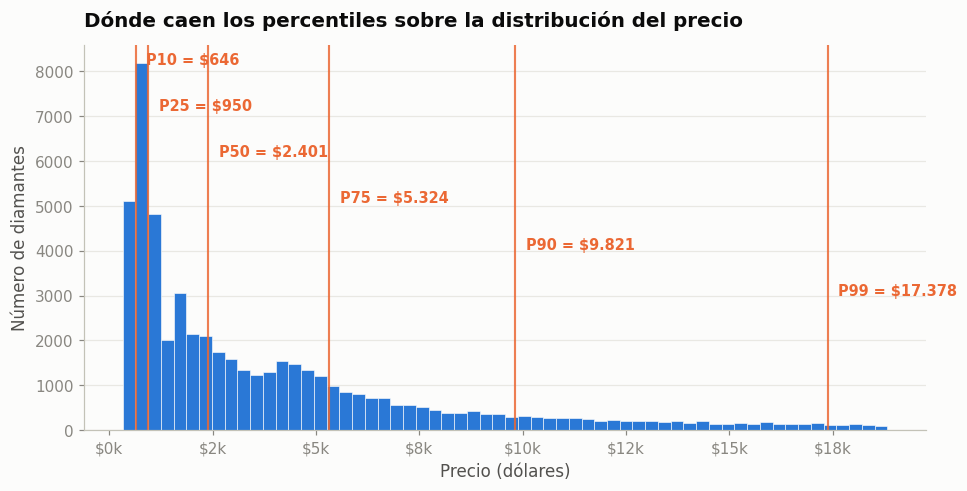

In [2]:
niveles = [10, 25, 50, 75, 90, 99]
fig, ax = plt.subplots(figsize=(9, 4.6))

ax.hist(precio, bins=60, color=AZUL, edgecolor="#fcfcfb", linewidth=0.4)

tope = ax.get_ylim()[1]
for k, alto in zip(niveles, [0.95, 0.83, 0.71, 0.59, 0.47, 0.35]):
    v = precio.quantile(k / 100)
    ax.axvline(v, color=NARANJA, linewidth=1.4, alpha=0.85)
    ax.text(v + 250, tope * alto, f"P{k} = ${v:,.0f}".replace(",", "."),
            color=NARANJA, fontsize=9.5, fontweight="bold")

ax.set_title("Dónde caen los percentiles sobre la distribución del precio")
ax.set_xlabel("Precio (dólares)"); ax.set_ylabel("Número de diamantes")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

🔍 **Para qué sirven de verdad.** Las medidas de posición son las que permiten decir
frases útiles sin promediar nada:

- «Este diamante está en el percentil 90: es más caro que el 90 % de los del catálogo.»
- «El 1 % más caro empieza en el P99.»
- «Entre el P25 y el P75 está la mitad central: es nuestro mercado principal.»

Y son la base de tres cosas que vienen después en el curso: el **diagrama de caja** (que ya
viste), los **intervalos de confianza** (sesión 10) y el **bootstrap** (sesión 9).

## 1.2 · Forma: la asimetría en un número

La distancia entre media y mediana ya nos decía si hay cola. El **coeficiente de asimetría**
(*skewness*) la resume en un número con signo:

$$g_1 = \frac{m_3}{m_2^{\,3/2}}
\qquad \text{donde} \qquad
m_k = \frac{1}{n}\sum_{i=1}^{n}\left(x_i - \bar{x}\right)^{k}$$

El numerador eleva al **cubo**, así que conserva el signo: las desviaciones por encima de la
media suman y las de por debajo restan. Si la cola está a la derecha, ganan las positivas. Y
como se divide por la desviación al cubo, el resultado **no tiene unidades**: se puede
comparar la asimetría de un precio en dólares con la de un peso en quilates.

> `pandas` calcula la versión corregida para muestras (Fisher-Pearson ajustada), que es la que
> verás en la tabla más abajo:
> $$G_1 = \frac{n}{(n-1)(n-2)}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^{3}$$

| Valor | Significa |
|---|---|
| **≈ 0** | Simétrica |
| **> 0** | Cola a la derecha (unos pocos valores muy altos) |
| **< 0** | Cola a la izquierda |

Como referencia gruesa: por debajo de 0,5 en valor absoluto la asimetría es leve; por encima
de 1 es fuerte.

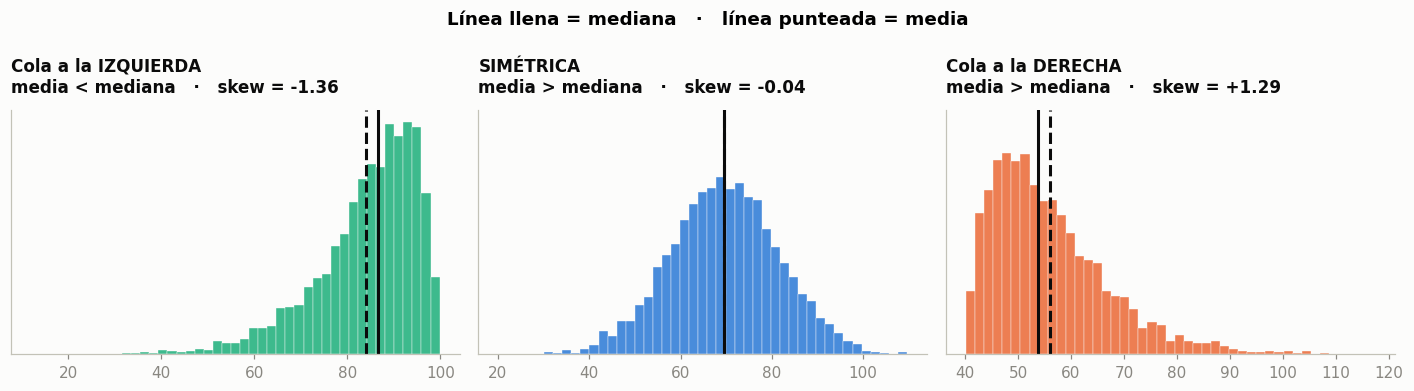

In [3]:
gen = np.random.default_rng(21)

izquierda = 100 - gen.gamma(2, 8, 4000)
simetrica = gen.normal(70, 12, 4000)
derecha = 40 + gen.gamma(2, 8, 4000)

casos = [("Cola a la IZQUIERDA", izquierda, VERDE),
         ("SIMÉTRICA", simetrica, AZUL),
         ("Cola a la DERECHA", derecha, NARANJA)]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)

for ax, (titulo, datos, color) in zip(axes, casos):
    ax.hist(datos, bins=45, color=color, alpha=0.85, edgecolor="#fcfcfb", linewidth=0.3)
    ax.axvline(np.median(datos), color=TINTA, linewidth=2)
    ax.axvline(np.mean(datos), color=TINTA, linewidth=2, linestyle="--")
    signo = "<" if np.mean(datos) < np.median(datos) else (">" if np.mean(datos) > np.median(datos) else "=")
    ax.set_title(f"{titulo}\nmedia {signo} mediana   ·   skew = {pd.Series(datos).skew():+.2f}",
                 fontsize=11)
    ax.set_yticks([])
    ax.grid(axis="y", alpha=0.5); ax.set_axisbelow(True)

fig.suptitle("Línea llena = mediana   ·   línea punteada = media",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

🔍 **El orden de las tres medidas delata la forma**

Cuando hay cola a la derecha, las tres se ordenan así:

> **moda < mediana < media**

La moda se queda en el pico, la mediana parte los datos en dos, y la media es la única que
se deja arrastrar por la cola. Con cola a la izquierda el orden se invierte; si es simétrica,
las tres coinciden.


## 1.2 bis · Forma: la curtosis

La asimetría dice **hacia dónde** se estira la distribución. La curtosis dice **cuánto pesan
las colas**, sin importar el lado:

$$g_2 = \frac{m_4}{m_2^{\,2}} - 3
\qquad \text{donde} \qquad
m_k = \frac{1}{n}\sum_{i=1}^{n}\left(x_i - \bar{x}\right)^{k}$$

El $-3$ del final es una convención: se resta para que **la normal quede exactamente en 0**.
Con esa resta el número se llama *curtosis en exceso*, y es la que devuelven `pandas` y casi
todos los programas.

| Valor | Nombre | Qué significa |
|---|---|---|
| **> 0** | Leptocúrtica | Colas **más pesadas** que la normal: los valores extremos aparecen más de lo esperado |
| **≈ 0** | Mesocúrtica | Colas como las de la normal |
| **< 0** | Platicúrtica | Colas **más ligeras**: casi no hay valores extremos |

> **El malentendido más común.** Se suele decir que la curtosis mide si la distribución es
> «más puntiaguda». No es cierto. Fíjate en la potencia **cuarta** de la fórmula: a un dato
> que está a 3 desviaciones de la media le asigna un peso de $3^4 = 81$, y a uno que está a
> media desviación, $0{,}5^4 = 0{,}0625$. Es más de mil veces más peso. **La curtosis es una
> medida de colas, no de pico.**

Comprobémoslo con tres distribuciones que tienen **la misma media y la misma desviación
estándar**, de modo que lo único que las diferencia son las colas.


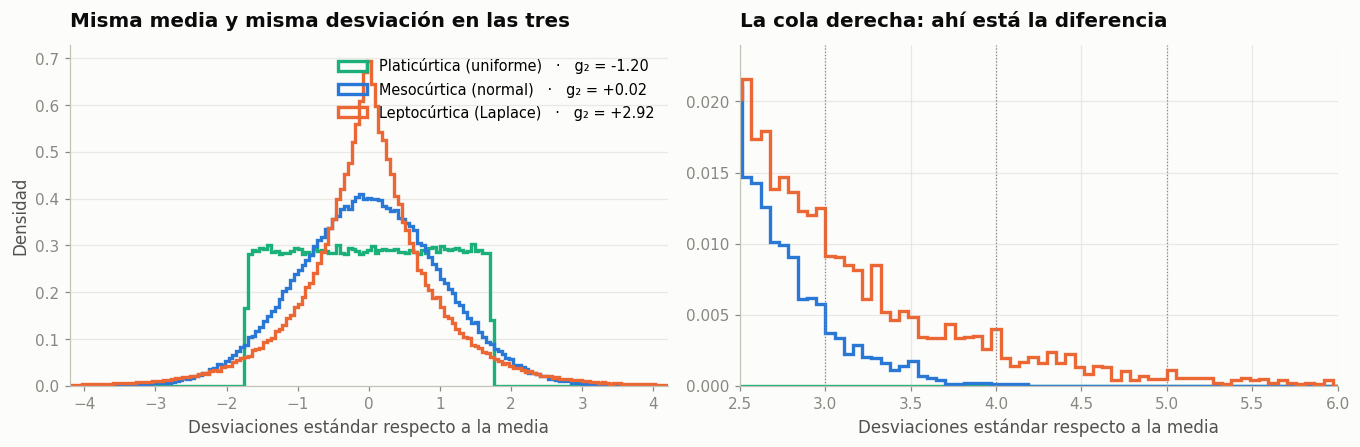

Proporción de datos más allá de 3 desviaciones estándar:

  Platicúrtica (uniforme)     0.00 %     (curtosis -1.20)
  Mesocúrtica (normal)        0.28 %     (curtosis +0.02)
  Leptocúrtica (Laplace)      1.43 %     (curtosis +2.92)


In [4]:
gen = np.random.default_rng(4)
n = 200_000

muestras = {
    "Platicúrtica (uniforme)": gen.uniform(-1, 1, n),
    "Mesocúrtica (normal)":    gen.normal(0, 1, n),
    "Leptocúrtica (Laplace)":  gen.laplace(0, 1, n),
}
# Se estandarizan las tres: media 0 y desviación 1. Así la única diferencia son las colas.
muestras = {k: (v - v.mean()) / v.std() for k, v in muestras.items()}
colores = {"Platicúrtica (uniforme)": VERDE,
           "Mesocúrtica (normal)": AZUL,
           "Leptocúrtica (Laplace)": NARANJA}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
bins = np.linspace(-7, 7, 260)

for nombre, v in muestras.items():
    g2 = pd.Series(v).kurtosis()
    for ax in (ax1, ax2):
        ax.hist(v, bins=bins, density=True, histtype="step", linewidth=2.2,
                color=colores[nombre],
                label=f"{nombre}   ·   g\u2082 = {g2:+.2f}" if ax is ax1 else None)

ax1.set_title("Misma media y misma desviación en las tres")
ax1.set_xlabel("Desviaciones estándar respecto a la media")
ax1.set_ylabel("Densidad")
ax1.set_xlim(-4.2, 4.2)
ax1.legend(loc="upper right", fontsize=9.5)
ax1.grid(axis="y", alpha=0.7); ax1.set_axisbelow(True)

ax2.set_title("La cola derecha: ahí está la diferencia")
ax2.set_xlabel("Desviaciones estándar respecto a la media")
ax2.set_xlim(2.5, 6); ax2.set_ylim(0, 0.024)
for x in (3, 4, 5):
    ax2.axvline(x, color=TENUE, linewidth=0.8, linestyle=":")
ax2.grid(alpha=0.7); ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("Proporción de datos más allá de 3 desviaciones estándar:\n")
for nombre, v in muestras.items():
    print(f"  {nombre:26s} {np.mean(np.abs(v) > 3) * 100:5.2f} %"
          f"     (curtosis {pd.Series(v).kurtosis():+.2f})")

🔍 **La uniforme no tiene colas y la Laplace las tiene larguísimas.**

Mira el panel de la derecha: más allá de tres desviaciones estándar la uniforme **no tiene un
solo dato**, la normal tiene unos pocos y la Laplace tiene bastantes. Las tres tienen la misma
media y la misma desviación; lo único que cambia es cuánta masa hay en los extremos, y eso es
exactamente lo que mide la curtosis.

> **Por qué te va a servir.** Una curtosis alta es un aviso anticipado: **va a haber
> atípicos**, y las medidas no robustas van a sufrir. Es el puente hacia el bloque 2.


In [5]:
forma = pd.DataFrame({
    "media": [df[c].mean() for c in ["price", "carat", "depth", "table"]],
    "mediana": [df[c].median() for c in ["price", "carat", "depth", "table"]],
    "asimetría": [df[c].skew() for c in ["price", "carat", "depth", "table"]],
    "curtosis": [df[c].kurtosis() for c in ["price", "carat", "depth", "table"]],
}, index=["price", "carat", "depth", "table"]).round(2)
forma["lectura"] = np.where(forma["asimetría"] > 1, "cola derecha FUERTE",
                     np.where(forma["asimetría"] > 0.5, "cola derecha leve",
                       np.where(forma["asimetría"] < -0.5, "cola izquierda", "casi simétrica")))
forma

,media,mediana,asimetría,curtosis,lectura
price,3932.80,2401.0,1.62,2.18,cola derecha FUERTE
carat,0.80,0.7,1.12,1.26,cola derecha FUERTE
depth,61.75,61.8,-0.08,5.74,casi simétrica
table,57.46,57.0,0.80,2.80,cola derecha leve


> **Sobre la curtosis.** Mide cuánto pesan las colas frente a una distribución normal
> (cuya curtosis, en esta convención, es 0). Un valor alto significa **más valores extremos
> de lo esperado**, no «más puntiaguda» — esa es la interpretación popular y es incorrecta.
> Fíjate en `depth`: su curtosis es enorme, y eso anticipa exactamente lo que vamos a
> encontrar en el bloque 2.

## 1.3 · Robustez: qué se mueve y qué no

Una medida es **robusta** si un puñado de valores extremos no la altera. Es la propiedad que
decide qué medida usar cuando los datos vienen sucios — y los datos siempre vienen sucios.

Un solo dato basta para demostrarlo.

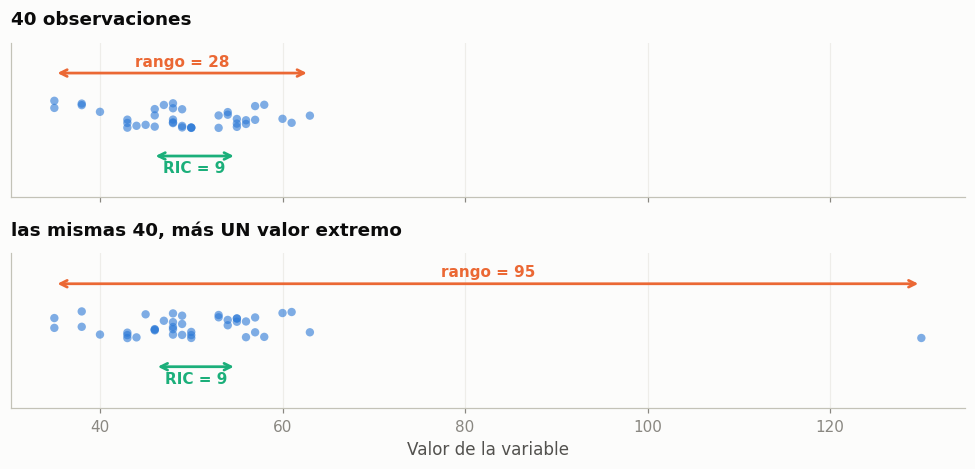

In [6]:
gen = np.random.default_rng(11)
base = np.round(gen.normal(50, 8, 40))
con_extremo = np.append(base, 130)                      # un solo dato lejano

fig, axes = plt.subplots(2, 1, figsize=(9, 4.4), sharex=True)

for ax, datos, titulo in zip(axes, [base, con_extremo],
                             ["40 observaciones", "las mismas 40, más UN valor extremo"]):
    a1, a3 = np.percentile(datos, [25, 75])
    salto = gen.uniform(-0.25, 0.25, len(datos))
    ax.scatter(datos, salto, s=30, color=AZUL, alpha=0.6, edgecolors="none")

    # rango completo (arriba) y rango intercuartilico (abajo)
    ax.annotate("", xy=(datos.min(), 0.75), xytext=(datos.max(), 0.75),
                arrowprops=dict(arrowstyle="<->", color=NARANJA, linewidth=1.8))
    ax.text((datos.min() + datos.max()) / 2, 0.88,
            f"rango = {datos.max() - datos.min():.0f}",
            ha="center", color=NARANJA, fontweight="bold", fontsize=10)

    ax.annotate("", xy=(a1, -0.75), xytext=(a3, -0.75),
                arrowprops=dict(arrowstyle="<->", color=VERDE, linewidth=1.8))
    ax.text((a1 + a3) / 2, -1.05, f"RIC = {a3 - a1:.0f}",
            ha="center", color=VERDE, fontweight="bold", fontsize=10)

    ax.set_ylim(-1.5, 1.3); ax.set_yticks([])
    ax.set_title(titulo, fontsize=12)
    ax.grid(axis="x", alpha=0.5); ax.set_axisbelow(True)

axes[-1].set_xlabel("Valor de la variable")
fig.tight_layout()
plt.show()

🔍 **El rango se cuadruplicó; el RIC no se movió.**

El rango depende **exclusivamente** de los dos valores más raros de la base. El RIC mira el
50 % central y le da igual lo que pase en los extremos. La misma lógica separa la media de
la mediana.

Pongámoslo en una tabla.

### La MAD: la desviación estándar del mundo real

En la tabla que sigue aparece una medida que no habíamos visto. La **desviación absoluta
mediana** (MAD, *median absolute deviation*) es a la desviación estándar lo que la mediana es
a la media:

$$\text{MAD} = \text{mediana}\big(\; |x_i - \text{mediana}(x)| \;\big)$$

Se lee de dentro hacia afuera: primero la mediana, después **cuánto se aleja cada dato de
ella**, y por último la mediana de esas distancias. La desviación estándar hace lo mismo pero
partiendo de la media y **elevando al cuadrado** — y ese cuadrado es justo lo que la vuelve
frágil ante un valor extremo.

> **Cuándo usarla.** Cuando necesites reportar dispersión y sospeches que hay valores
> extremos. Si quieres compararla con una desviación estándar, multiplícala por **1,4826**:
> con ese factor las dos coinciden cuando los datos son normales.


In [7]:
gen = np.random.default_rng(11)
base = np.round(gen.normal(50, 8, 40))
con_extremo = np.append(base, 130)

def mad(v):
    """Desviación absoluta mediana: la alternativa robusta a la desviación estándar."""
    return np.median(np.abs(v - np.median(v)))

filas = []
for nombre, v in [("40 observaciones", base), ("+ un valor de 130", con_extremo)]:
    q1, q3 = np.percentile(v, [25, 75])
    filas.append({"conjunto": nombre, "media": v.mean(), "mediana": np.median(v),
                  "desv. est.": v.std(), "RIC": q3 - q1, "MAD": mad(v),
                  "rango": v.max() - v.min()})

comp = pd.DataFrame(filas).set_index("conjunto").round(2)
comp.loc["cambio %"] = (comp.iloc[1] / comp.iloc[0] - 1) * 100
comp.round(1)

,media,mediana,desv. est.,RIC,MAD,rango
conjunto,,,,,,
40 observaciones,49.3,49.0,6.8,9.2,5.0,28.0
+ un valor de 130,51.3,49.0,14.2,9.0,5.0,95.0
cambio %,4.0,0.0,107.8,-2.7,0.0,239.3


🔍 **Léelo por la última fila.**

| Medida | ¿Robusta? | Qué le pasó |
|---|---|---|
| **Mediana** | **Sí** | Prácticamente no se movió |
| **RIC** | **Sí** | Prácticamente no se movió |
| **MAD** | **Sí** | Prácticamente no se movió |
| Media | No | Subió |
| Desviación estándar | No | Subió mucho |
| Rango | No | Se disparó |

> **La regla operativa:** si sospechas que hay extremos —y siempre los hay—, reporta
> **mediana y RIC**. Si necesitas media y desviación para un modelo, primero decide qué vas
> a hacer con los extremos. Que es justo el bloque siguiente.

---
---
# Bloque 2 · Valores atípicos

Un atípico es un valor **lejano de los demás**. Nada más. No es un error, no es un fraude, y
no es necesariamente algo que haya que quitar.

Lo primero es que «lejano» necesita una definición operativa, y hay más de una.

### Regla 1 · La **regla de Tukey** (o del rango intercuartílico)

La propuso **John Tukey** en 1977, y es la que dibuja el diagrama de caja. Define dos
«vallas» a partir de los cuartiles:

$$\text{Límite inferior} = Q_1 - 1{,}5 \times \text{RIC}
\qquad
\text{Límite superior} = Q_3 + 1{,}5 \times \text{RIC}$$

Todo lo que quede por fuera se marca como atípico.

**Por qué es robusta:** se apoya en cuartiles, que no se mueven por unos pocos valores
extremos. El atípico no puede «esconderse» corrompiendo la propia regla que debería
detectarlo.

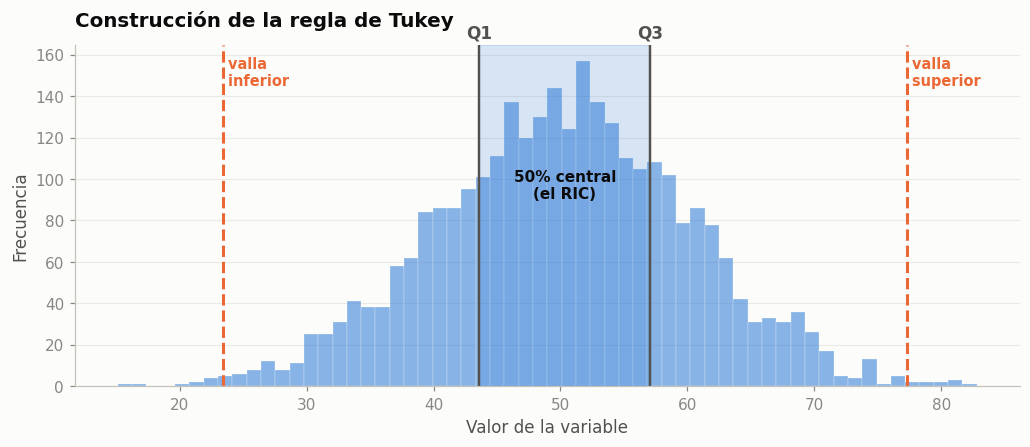

En una distribución simétrica, la regla marca alrededor del 0.6 % de los datos.


In [8]:
# Las vallas de Tukey sobre una distribución simétrica, para ver la construcción
gen = np.random.default_rng(5)
ejemplo = gen.normal(50, 10, 3000)
e_q1, e_q3 = np.percentile(ejemplo, [25, 75])
e_ric = e_q3 - e_q1
valla_inf, valla_sup = e_q1 - 1.5 * e_ric, e_q3 + 1.5 * e_ric

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.hist(ejemplo, bins=60, color=AZUL, alpha=0.55, edgecolor="#fcfcfb", linewidth=0.3)

ax.axvspan(e_q1, e_q3, color=AZUL, alpha=0.18)
for v, etq, col in [(e_q1, "Q1", TINTA2), (e_q3, "Q3", TINTA2)]:
    ax.axvline(v, color=col, linewidth=1.6)
for v, etq in [(valla_inf, "Q1 − 1,5·RIC"), (valla_sup, "Q3 + 1,5·RIC")]:
    ax.axvline(v, color=NARANJA, linewidth=2, linestyle="--")

tope = ax.get_ylim()[1]
ax.text(e_q1, tope * 1.02, "Q1", ha="center", color=TINTA2, fontweight="bold")
ax.text(e_q3, tope * 1.02, "Q3", ha="center", color=TINTA2, fontweight="bold")
ax.text((e_q1 + e_q3) / 2, tope * 0.55, "50% central\n(el RIC)", ha="center",
        color=TINTA, fontsize=10, fontweight="bold")
ax.text(valla_inf, tope * 0.88, " valla\n inferior", color=NARANJA, fontsize=9.5, fontweight="bold")
ax.text(valla_sup, tope * 0.88, " valla\n superior", color=NARANJA, fontsize=9.5, fontweight="bold")

ax.set_title("Construcción de la regla de Tukey")
ax.set_xlabel("Valor de la variable"); ax.set_ylabel("Frecuencia")
ax.grid(axis="y", alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

fuera = ((ejemplo < valla_inf) | (ejemplo > valla_sup)).mean() * 100
print(f"En una distribución simétrica, la regla marca alrededor del {fuera:.1f} % de los datos.")

### Regla 2 · La **puntuación z** (estandarización)

Mide a cuántas desviaciones estándar está un valor de la media:

$$z = \frac{x - \bar{x}}{s}$$

Un valor con `z = 2` está dos desviaciones por encima de la media; con `z = -1,5`, una
desviación y media por debajo. La convención marca como atípico todo lo que supere
`|z| > 3`.

**Su punto débil:** usa la media y la desviación, y **ambas ya están contaminadas por el
propio atípico**. Un valor muy extremo infla `s`, y al inflarla deja de parecer lejano.

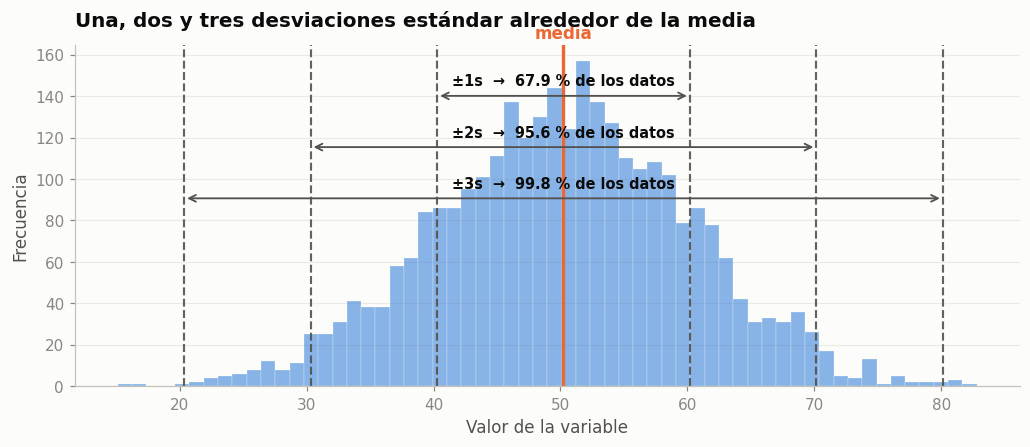

In [9]:
# Qué proporción de los datos cae dentro de 1, 2 y 3 desviaciones
gen = np.random.default_rng(5)
ejemplo = gen.normal(50, 10, 3000)
m_e, s_e = ejemplo.mean(), ejemplo.std()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.hist(ejemplo, bins=60, color=AZUL, alpha=0.55, edgecolor="#fcfcfb", linewidth=0.3)

ax.axvline(m_e, color=NARANJA, linewidth=2.2)
tope = ax.get_ylim()[1]
ax.text(m_e, tope * 1.02, "media", ha="center", color=NARANJA, fontweight="bold")

estilos = {1: (0.85, "1s"), 2: (0.70, "2s"), 3: (0.55, "3s")}
for k, (alto, etq) in estilos.items():
    for signo in (-1, 1):
        ax.axvline(m_e + signo * k * s_e, color=TINTA2, linewidth=1.4, linestyle="--", alpha=0.9)
    dentro = (np.abs(ejemplo - m_e) <= k * s_e).mean() * 100
    ax.annotate("", xy=(m_e - k * s_e, tope * alto), xytext=(m_e + k * s_e, tope * alto),
                arrowprops=dict(arrowstyle="<->", color=TINTA2, linewidth=1.2))
    ax.text(m_e, tope * (alto + 0.03), f"±{etq}  →  {dentro:.1f} % de los datos",
            ha="center", color=TINTA, fontsize=9.5, fontweight="bold")

ax.set_title("Una, dos y tres desviaciones estándar alrededor de la media")
ax.set_xlabel("Valor de la variable"); ax.set_ylabel("Frecuencia")
ax.grid(axis="y", alpha=0.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 2.3 · Las dos reglas, sobre los mismos datos

Escribimos las dos como funciones y las aplicamos a `price`.

In [10]:
def atipicos_ric(serie, k=1.5):
    """Marca como atípico lo que cae fuera de las vallas de Tukey."""
    q1, q3 = serie.quantile([0.25, 0.75])
    ric = q3 - q1
    return (serie < q1 - k * ric) | (serie > q3 + k * ric)


def atipicos_z(serie, umbral=3):
    """Marca como atípico lo que está a más de 'umbral' desviaciones de la media."""
    return ((serie - serie.mean()) / serie.std()).abs() > umbral

In [11]:

m_ric = atipicos_ric(precio)
m_z = atipicos_z(precio)

print(f"Regla del RIC : {m_ric.sum():5d} atípicos  ({m_ric.mean()*100:.1f} % de la base)")
print(f"Regla del z>3 : {m_z.sum():5d} atípicos  ({m_z.mean()*100:.1f} % de la base)")
print()
print(f"Marcados por AMBAS reglas    : {(m_ric & m_z).sum():5d}")
print(f"Solo por el RIC              : {(m_ric & ~m_z).sum():5d}")
print(f"Solo por el z                : {(m_z & ~m_ric).sum():5d}")

Regla del RIC :  3540 atípicos  (6.6 % de la base)
Regla del z>3 :  1206 atípicos  (2.2 % de la base)

Marcados por AMBAS reglas    :  1206
Solo por el RIC              :  2334
Solo por el z                :     0


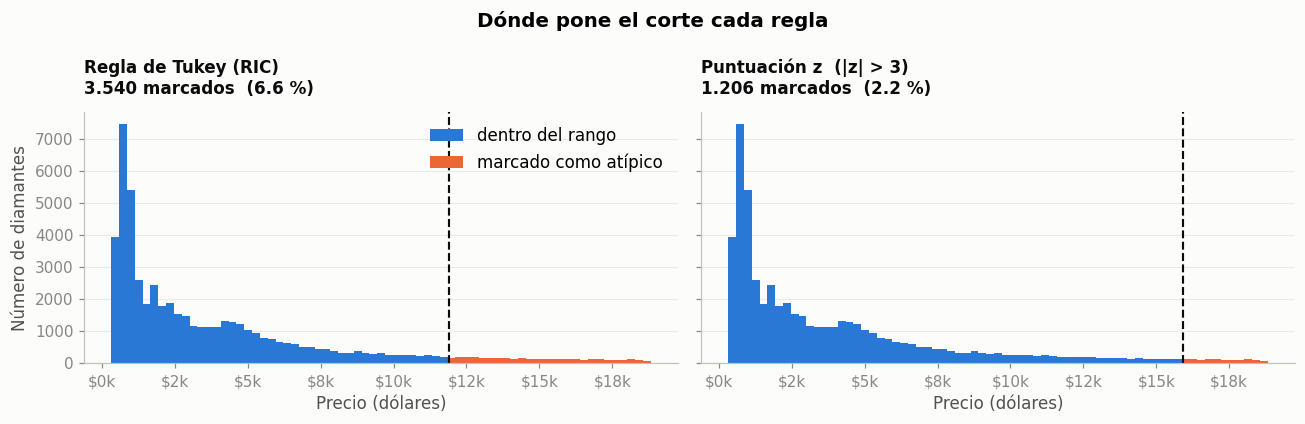

Regla de Tukey (RIC)       corta en $11.886
Puntuación z  (|z| > 3)    corta en $15.907


In [12]:
# Los mismos datos, marcando en cada panel lo que señala cada regla
reglas = [("Regla de Tukey (RIC)", m_ric), ("Puntuación z  (|z| > 3)", m_z)]
bins = np.linspace(precio.min(), precio.max(), 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)

for ax, (nombre, mascara) in zip(axes, reglas):
    ax.hist(precio[~mascara], bins=bins, color=AZUL, label="dentro del rango")
    ax.hist(precio[mascara], bins=bins, color=NARANJA, label="marcado como atípico")
    corte = precio[mascara].min()
    ax.axvline(corte, color=TINTA, linewidth=1.4, linestyle="--")
    ax.set_title(f"{nombre}\n{mascara.sum():,} marcados  ({mascara.mean()*100:.1f} %)".replace(",", "."),
                 fontsize=11)
    ax.set_xlabel("Precio (dólares)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
    ax.grid(axis="y", alpha=0.6); ax.set_axisbelow(True)

axes[0].set_ylabel("Número de diamantes")
axes[0].legend(loc="upper right")

fig.suptitle("Dónde pone el corte cada regla", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

for nombre, mascara in reglas:
    print(f"{nombre:26s} corta en ${precio[mascara].min():,.0f}".replace(",", "."))

🔍 **Ninguna de las dos es «la verdad»**

El conjunto que marca el z está **enteramente contenido** en el que marca Tukey: 1.206 de
los 3.540. Dos conclusiones:

1. **Son convenciones, no descubrimientos.** El 1,5 y el 3 son números elegidos por
   costumbre. Cambiar el umbral cambia cuántos «atípicos» tienes.
2. **En distribuciones muy asimétricas la regla del RIC marca muchísimo.** Aquí señala
   miles de diamantes perfectamente legítimos: son simplemente caros.

Y hay una tercera, más incómoda: la regla del z **usa la media y la desviación, que ya
están contaminadas por el propio atípico**. Un valor muy extremo infla `s`, y al inflarla
deja de parecer lejano. Se esconde detrás de su propio efecto.

In [13]:
# El atípico que se esconde: un solo valor absurdo y qué le hace a cada regla
p = precio.copy()
p_con_error = pd.concat([p, pd.Series([1_800_000])], ignore_index=True)   # un cero de más

for nombre, s in [("sin el error", p), ("con un precio de 1.800.000", p_con_error)]:
    z = ((s - s.mean()) / s.std()).abs()
    print(f"{nombre:30s} desv.est. = {s.std():>10,.0f}".replace(",", ".") +
          f"   |  z del valor máximo = {z.max():5.1f}   " +
          f"|  marcados por z>3: {(z > 3).sum():,}".replace(",", "."))

sin el error                   desv.est. =      3.989   |  z del valor máximo =   3.7   |  marcados por z>3: 1.206
con un precio de 1.800.000     desv.est. =      8.702   |  z del valor máximo = 206.4   |  marcados por z>3: 1


> **Ahí está el problema.** Al meter un solo valor absurdo, la desviación estándar se
> dispara, y con ella el denominador de la puntuación z. El resultado es que la regla marca
> **menos** atípicos que antes: el error tapó a los demás. La regla de Tukey, que se apoya
> en cuartiles, no se inmuta.

## 2.4 · Los cuatro impactos de un valor extremo

### Impacto 1 · En la visualización

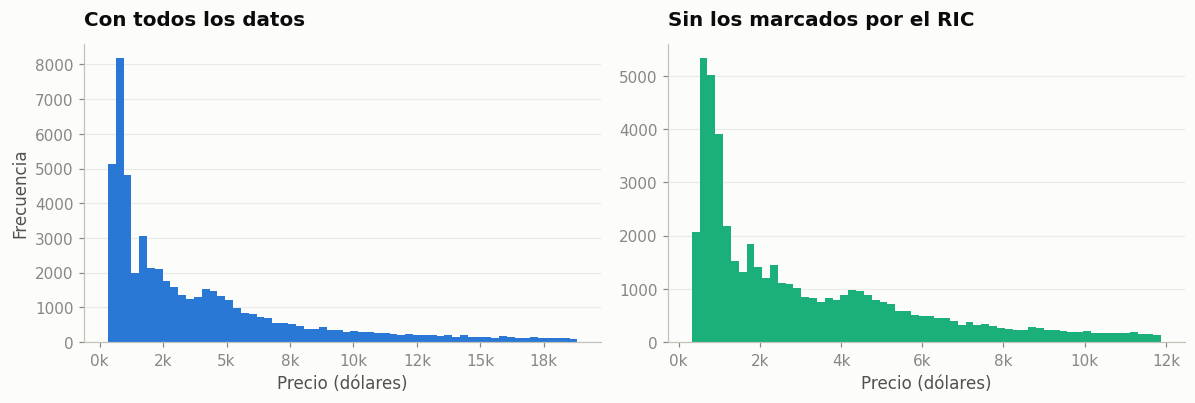

Rango con todos : $326 – $18.823
Rango sin ellos : $326 – $11.883

El primer tercio del eje llega hasta $6.274
y ahí se concentra el 80 % de los diamantes.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.hist(precio, bins=60, color=AZUL)
ax1.set_title("Con todos los datos")
ax1.set_xlabel("Precio (dólares)"); ax1.set_ylabel("Frecuencia")
ax1.grid(axis="y", alpha=0.6); ax1.set_axisbelow(True)

ax2.hist(precio[~m_ric], bins=60, color=VERDE)
ax2.set_title("Sin los marcados por el RIC")
ax2.set_xlabel("Precio (dólares)")
ax2.grid(axis="y", alpha=0.6); ax2.set_axisbelow(True)

for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x/1000:,.0f}k".replace(",", ".")))

fig.tight_layout()
plt.show()

print(f"Rango con todos : ${precio.min():,.0f} – ${precio.max():,.0f}".replace(",", "."))
print(f"Rango sin ellos : ${precio.min():,.0f} – ${precio[~m_ric].max():,.0f}".replace(",", "."))
print()

# ¿Qué porcentaje de diamantes cabe en el primer tercio del eje?
tercio = precio.max() / 3
print(f"El primer tercio del eje llega hasta ${tercio:,.0f}".replace(",", "."))
print(f"y ahí se concentra el {(precio <= tercio).mean()*100:.0f} % de los diamantes.")

🔍 **El extremo se lleva el eje.** Con todos los datos, la mayoría de los diamantes se
apelmaza contra el borde izquierdo y no se distingue nada dentro de ese bloque. Al recortar,
el mismo grupo ocupa el ancho completo.

**Ojo:** esto **no** es una razón para borrar los extremos. Es una razón para *mirar* con
otra escala — que es distinto, y es el bloque 3.

### Impacto 2 · En el escalado, y por lo tanto en los modelos

Muchos algoritmos exigen llevar las variables a un rango común. La normalización mín-máx es
la más usada:

$$x_{\text{escalado}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**El denominador depende exclusivamente del mínimo y del máximo.** Basta un valor extremo
para estirarlo y aplastar a todos los demás contra el cero.

In [15]:
def resolucion_central(v):
    """Cuánto del rango 0-1 ocupa el 50 % central tras normalizar mín-máx."""
    e = (v - v.min()) / (v.max() - v.min())
    q1, q3 = np.percentile(e, [25, 75])
    return q3 - q1

m_ric = atipicos_ric(precio)
casos = {
    "price tal como está":            precio.values,
    "price sin los marcados por RIC": precio[~m_ric].values,
    "price + UN error de digitación": np.append(precio.values, 1_800_000),
}
for nombre, v in casos.items():
    print(f"{nombre:34s} el 50 % central ocupa {resolucion_central(v):.3f} del rango 0-1")

price tal como está                el 50 % central ocupa 0.236 del rango 0-1
price sin los marcados por RIC     el 50 % central ocupa 0.325 del rango 0-1
price + UN error de digitación     el 50 % central ocupa 0.002 del rango 0-1


🔍 **Un solo error de digitación entre 53.940 filas** comprime el 50 % central a una
franja diminuta. Para un modelo que mide **distancias** —vecinos más cercanos,
conglomerados, redes neuronales— eso es fatal: deja de poder distinguir casos que sí son
distintos.

> Por eso en la práctica se prefiere la **estandarización robusta** (basada en mediana y
> RIC), que no depende del máximo, o se transforma la variable antes de escalar.

### Impacto 3 · En la regresión

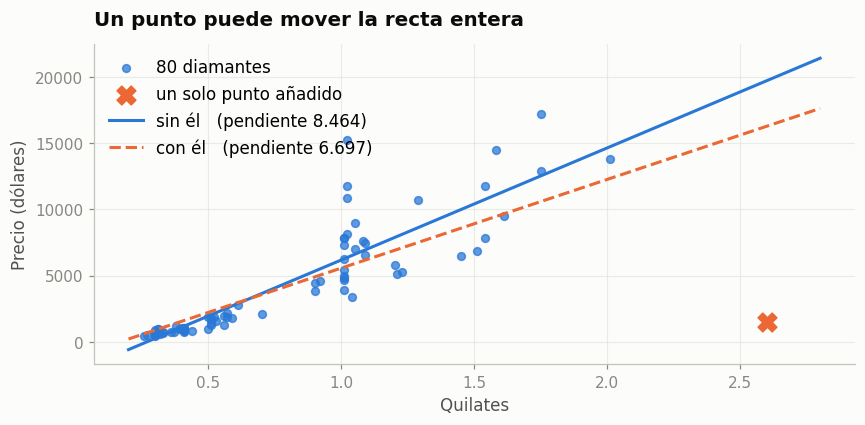

La pendiente cayó un 21 % por añadir UN dato entre 81.


In [16]:
rng = np.random.default_rng(3)
muestra = df.sample(80, random_state=3)
x, y = muestra["carat"].values, muestra["price"].values

# Un punto influyente: un diamante grande y sospechosamente barato
x_at, y_at = 2.6, 1500
x2, y2 = np.append(x, x_at), np.append(y, y_at)

m1, b1 = np.polyfit(x, y, 1)
m2, b2 = np.polyfit(x2, y2, 1)
rejilla = np.linspace(0.2, 2.8, 50)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, s=26, color=AZUL, alpha=0.75, label="80 diamantes")
ax.scatter([x_at], [y_at], s=150, color=NARANJA, zorder=5, marker="X",
           label="un solo punto añadido")
ax.plot(rejilla, m1 * rejilla + b1, color=AZUL, linewidth=2, label=f"sin él   (pendiente {m1:,.0f})".replace(",", "."))
ax.plot(rejilla, m2 * rejilla + b2, color=NARANJA, linewidth=2, linestyle="--",
        label=f"con él   (pendiente {m2:,.0f})".replace(",", "."))

ax.set_title("Un punto puede mover la recta entera")
ax.set_xlabel("Quilates"); ax.set_ylabel("Precio (dólares)")
ax.grid(alpha=0.6); ax.set_axisbelow(True)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"La pendiente cayó un {(1 - m2/m1)*100:.0f} % por añadir UN dato entre 81.")

🔍 **Un dato entre 81 cambió la conclusión del modelo.** La pendiente responde «¿cuánto
sube el precio por cada quilate adicional?», y un solo punto la movió sustancialmente.

Esto tiene nombre —**apalancamiento**— y ocurre sobre todo cuando el punto extremo está
lejos en el eje horizontal. En la sesión 13 lo detectaremos con el análisis de residuos.

### Impacto 4 · En la función de error

Casi todos los modelos se ajustan minimizando el **error cuadrático medio**. La palabra
clave es *cuadrático*.

In [17]:
errores = np.array([2, -3, 1, -2, 200])      # cuatro errores normales y uno enorme

cuadrados = errores ** 2
peso = cuadrados / cuadrados.sum() * 100

tabla = pd.DataFrame({"error": errores, "error²": cuadrados,
                      "% del error total": peso.round(2)})
print(tabla.to_string(index=False))
print()
print(f"El caso extremo aporta el {peso[-1]:.2f} % del error cuadrático total,")
print(f"pero es 1 de 5 observaciones ({1/5*100:.0f} % de los datos).")

 error  error²  % del error total
     2       4               0.01
    -3       9               0.02
     1       1               0.00
    -2       4               0.01
   200   40000              99.96

El caso extremo aporta el 99.96 % del error cuadrático total,
pero es 1 de 5 observaciones (20 % de los datos).


🔍 **Un solo caso se lleva el 99,96 % del error.** Al ajustar, el modelo va a dedicar su
esfuerzo a ese caso y a empeorar en los otros cuatro.

> **Consecuencia práctica:** un atípico no solo distorsiona tus descriptivos. Distorsiona
> **hacia dónde apunta el modelo**. Por eso, cuando hay extremos legítimos, a veces se cambia
> la función de error o se transforma la variable — no se borra el dato.

## 2.5 · Entonces, ¿qué se hace con ellos?

No hay respuesta universal. Hay un menú, y la elección depende de **tu objetivo** y de **qué
modelo vas a construir**.

| Opción | Cuándo tiene sentido | Riesgo |
|---|---|---|
| **Conservar** | El valor es legítimo y es parte de lo que estudias | Distorsiona medias, escalas y modelos sensibles |
| **Marcar con indicador** | Quieres poder excluirlos después sin perderlos | Ninguno; es casi siempre lo mínimo razonable |
| **Transformar** (log) | La variable es muy asimétrica y positiva | Cambia la interpretación: ya no hablas de dólares |
| **Winsorizar** (topar en un percentil) | Necesitas limitar la influencia sin borrar filas | Inventas valores que nadie observó |
| **Modelar aparte** | Los extremos son un fenómeno distinto | Reduce el tamaño de cada grupo |
| **Eliminar** | Puedes **demostrar** que es un error de medición | Si te equivocas, borras la señal que buscabas |

## 2.6 · La opción más útil en analítica: transformar

Antes de borrar nada, prueba cambiar la escala en que miras la variable.

In [18]:
log_precio = np.log(precio)

antes = atipicos_ric(precio).sum()
despues = atipicos_ric(log_precio).sum()

print(f"Atípicos según Tukey en price       : {antes:,}".replace(",", "."))
print(f"Atípicos según Tukey en log(price)  : {despues:,}".replace(",", "."))
print()
print(f"Asimetría de price      : {precio.skew():+.2f}")
print(f"Asimetría de log(price) : {log_precio.skew():+.2f}")
print()
print(f"Filas eliminadas: 0   (siguen los {len(df):,} diamantes)".replace(",", "."))

Atípicos según Tukey en price       : 3.540
Atípicos según Tukey en log(price)  : 0

Asimetría de price      : +1.62
Asimetría de log(price) : +0.12

Filas eliminadas: 0   (siguen los 53.940 diamantes)


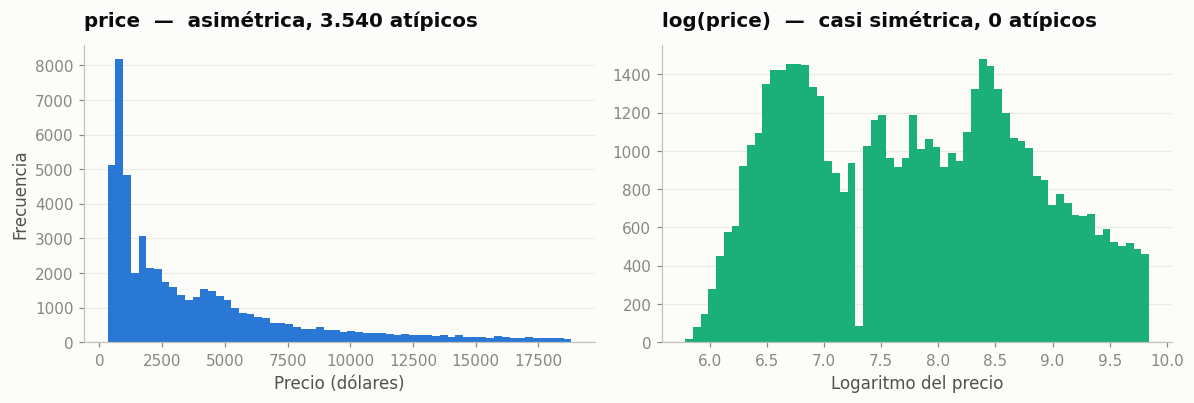

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.hist(precio, bins=60, color=AZUL)
ax1.set_title("price  —  asimétrica, 3.540 atípicos")
ax1.set_xlabel("Precio (dólares)"); ax1.set_ylabel("Frecuencia")
ax1.grid(axis="y", alpha=0.6); ax1.set_axisbelow(True)

ax2.hist(log_precio, bins=60, color=VERDE)
ax2.set_title("log(price)  —  casi simétrica, 0 atípicos")
ax2.set_xlabel("Logaritmo del precio")
ax2.grid(axis="y", alpha=0.6); ax2.set_axisbelow(True)

fig.tight_layout()
plt.show()

🔍 **Los atípicos desaparecieron sin borrar una sola fila.** Lo que cambió no son los
datos: es la **escala en que los miramos**.

> **Por qué funciona.** El logaritmo comprime los valores grandes mucho más que los
> pequeños. En variables de dinero, ventas, ingresos o tiempos —que casi siempre tienen cola
> derecha— es la primera herramienta que hay que probar, **antes** de pensar en eliminar.

> **El costo, y hay que declararlo.** Ya no modelas dólares sino logaritmos de dólares. Los
> coeficientes se interpretan en términos porcentuales, no absolutos. Lo veremos en la
> sesión 13.

## 2.7 · Las cinco reglas que se llevan del bloque

> 1. **Un atípico estadístico no es un error.** Detectarlo es el principio del análisis, no
>    el final.
> 2. **Eliminar solo se justifica si puedes demostrar que es un error de medición**, y se
>    documenta en la bitácora.
> 3. **Antes de eliminar, prueba transformar.** Suele resolver el problema sin perder datos.
> 4. **Marca siempre**, hagas lo que hagas. Una columna indicadora cuesta una línea.
> 5. **La decisión depende del objetivo y del modelo.** No hay respuesta universal, y quien
>    diga lo contrario no ha trabajado con datos reales.

---
---
# Bloque 3 · Escalas, ejes y honestidad visual

Todo lo anterior fue sobre los datos. Este bloque es sobre **el dibujo**, y sobre las cuatro
formas de mentir sin falsificar un solo número.

## 3.1 · El eje truncado

En un gráfico de barras **la longitud es el dato**. Si el eje no empieza en cero, la longitud
deja de ser proporcional al valor y el gráfico miente.

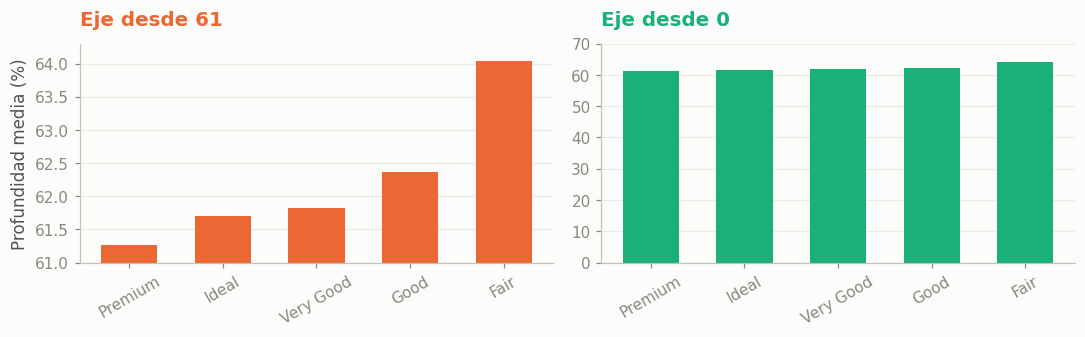

Valores reales:
cut
Premium      61.26
Ideal        61.71
Very Good    61.82
Good         62.37
Fair         64.04


In [20]:
prom_depth = df.groupby("cut", observed=True)["depth"].mean().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))

# --- Izquierda: eje recortado
ax1.bar(prom_depth.index.astype(str), prom_depth.values, color=NARANJA, width=0.6)
ax1.set_ylim(61, 64.3)
ax1.set_title("Eje desde 61", color=NARANJA)
ax1.set_ylabel("Profundidad media (%)")
ax1.grid(axis="y", alpha=0.6); ax1.set_axisbelow(True)
ax1.tick_params(axis="x", rotation=30)

# --- Derecha: eje desde cero
ax2.bar(prom_depth.index.astype(str), prom_depth.values, color=VERDE, width=0.6)
ax2.set_ylim(0, 70)
ax2.set_title("Eje desde 0", color=VERDE)
ax2.grid(axis="y", alpha=0.6); ax2.set_axisbelow(True)
ax2.tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

print("Valores reales:")
print(prom_depth.round(2).to_string())

🔍 **La diferencia real entre la mayor y la menor es de menos de tres puntos** sobre una
escala de 0 a 100. El gráfico de la izquierda sugiere que los diamantes `Fair` son
dramáticamente más profundos. No lo son.

| Tipo de gráfico | ¿El eje debe empezar en cero? |
|---|---|
| **Barras, áreas, burbujas** | **Sí, siempre.** La longitud o el área codifican el valor |
| **Líneas y dispersión** | **No necesariamente.** Lo que codifica el valor es la posición, no la longitud |

> La excepción de las líneas tiene su propio límite: si recortas tanto que una variación del
> 0,3 % llena la pantalla, estás haciendo lo mismo con otro nombre.

## 3.2 · La escala desigual

Más sutil y más peligroso: el eje empieza en cero, pero sus marcas **no están a distancias
proporcionales**.

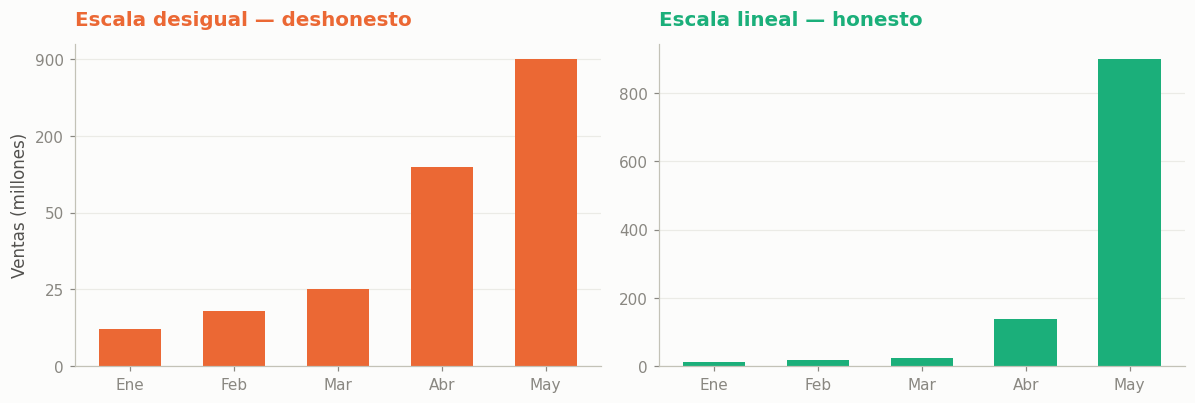

Valores reales: {'Ene': 12, 'Feb': 18, 'Mar': 25, 'Abr': 140, 'May': 900}


In [21]:
ventas = pd.Series([12, 18, 25, 140, 900],
                   index=["Ene", "Feb", "Mar", "Abr", "May"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

# --- Izquierda: marcas del eje a distancias arbitrarias (deshonesto)
posiciones = [0, 25, 50, 75, 100]
etiquetas = [0, 25, 50, 200, 900]
valores_falsos = np.interp(ventas.values, etiquetas, posiciones)
ax1.bar(ventas.index, valores_falsos, color=NARANJA, width=0.6)
ax1.set_yticks(posiciones); ax1.set_yticklabels(etiquetas)
ax1.set_title("Escala desigual — deshonesto", color=NARANJA)
ax1.set_ylabel("Ventas (millones)")
ax1.grid(axis="y", alpha=0.6); ax1.set_axisbelow(True)

# --- Derecha: escala lineal de verdad
ax2.bar(ventas.index, ventas.values, color=VERDE, width=0.6)
ax2.set_title("Escala lineal — honesto", color=VERDE)
ax2.grid(axis="y", alpha=0.6); ax2.set_axisbelow(True)

fig.tight_layout()
plt.show()

print("Valores reales:", ventas.to_dict())

🔍 **A la izquierda, mayo apenas duplica a abril; a la derecha lo multiplica por más de
seis.** Las etiquetas del eje son correctas una por una. Lo que está mal es que **la
distancia entre 50 y 200 ocupa lo mismo que la distancia entre 0 y 25**.

> **Cómo detectarlo:** mira las marcas del eje y comprueba que los saltos entre ellas sean
> iguales. Si van 0, 10, 50, 100, 500, el gráfico está deformado.

### El caso legítimo: la escala logarítmica

Una escala logarítmica también tiene marcas a distancias desiguales, y **es perfectamente
honesta** — siempre que se declare. La diferencia es que el criterio es explícito y
constante: cada salto multiplica por diez.

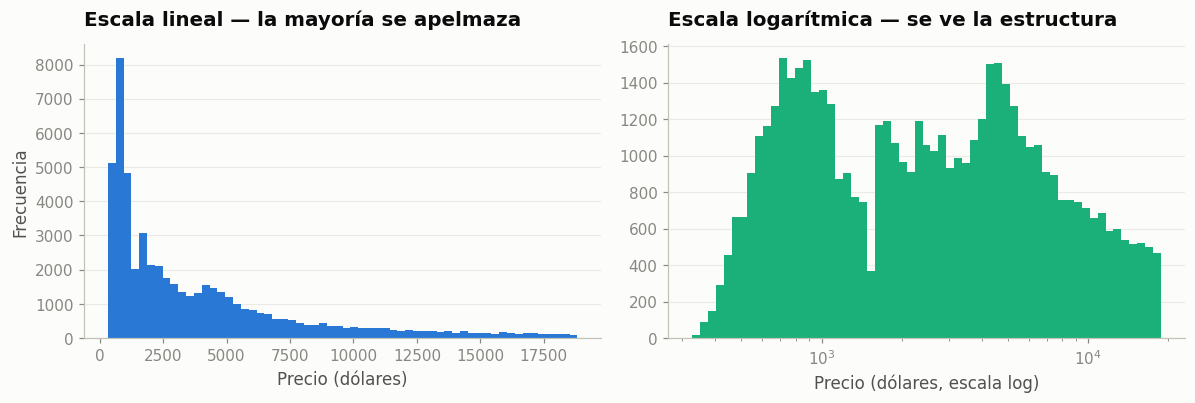

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.hist(precio, bins=60, color=AZUL)
ax1.set_title("Escala lineal — la mayoría se apelmaza")
ax1.set_xlabel("Precio (dólares)"); ax1.set_ylabel("Frecuencia")
ax1.grid(axis="y", alpha=0.6); ax1.set_axisbelow(True)

ax2.hist(precio, bins=np.logspace(np.log10(precio.min()), np.log10(precio.max()), 60),
         color=VERDE)
ax2.set_xscale("log")
ax2.set_title("Escala logarítmica — se ve la estructura")
ax2.set_xlabel("Precio (dólares, escala log)")
ax2.grid(axis="y", alpha=0.6); ax2.set_axisbelow(True)

fig.tight_layout()
plt.show()

> **La regla de la escala logarítmica:** úsala cuando la variable abarque varios órdenes de
> magnitud, **dilo en el título o en el eje**, y nunca la uses en un gráfico de barras
> —porque entonces la longitud vuelve a no ser proporcional al valor—.

## 3.3 · El agrupamiento tendencioso

Ya lo viste ayer con el ancho de las barras, pero vale la pena verlo como lo que es: **una
forma de ocultar un hallazgo sin borrar nada**.

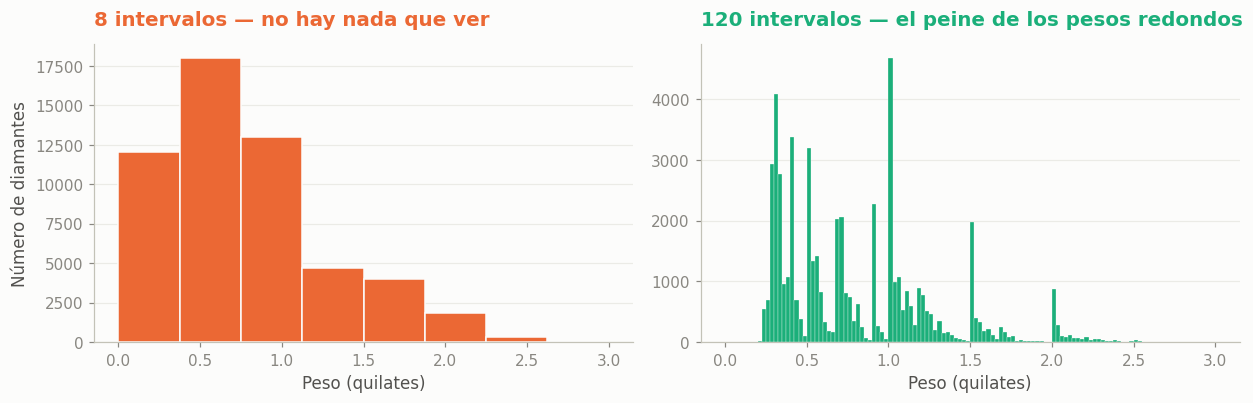

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=False)

ax1.hist(carat, bins=8, range=(0, 3), color=NARANJA, edgecolor="#fcfcfb")
ax1.set_title("8 intervalos — no hay nada que ver", color=NARANJA)
ax1.set_xlabel("Peso (quilates)"); ax1.set_ylabel("Número de diamantes")
ax1.grid(axis="y", alpha=0.6); ax1.set_axisbelow(True)

ax2.hist(carat, bins=120, range=(0, 3), color=VERDE, edgecolor="#fcfcfb", linewidth=0.2)
ax2.set_title("120 intervalos — el peine de los pesos redondos", color=VERDE)
ax2.set_xlabel("Peso (quilates)")
ax2.grid(axis="y", alpha=0.6); ax2.set_axisbelow(True)

fig.tight_layout()
plt.show()

🔍 **Los datos son idénticos.** A la izquierda no hay ningún patrón; a la derecha está el
descubrimiento que vimos ayer. Quien quiera sostener que «no hay estructura» solo tiene que
elegir ocho intervalos y nadie podrá acusarlo de falsificar nada.

## 3.4 · El área mal codificada

El cuarto pecado, y el más difícil de ver. Cuando el tamaño de un símbolo representa una
cantidad, **lo que el ojo compara es el área**, no el radio ni el ancho.

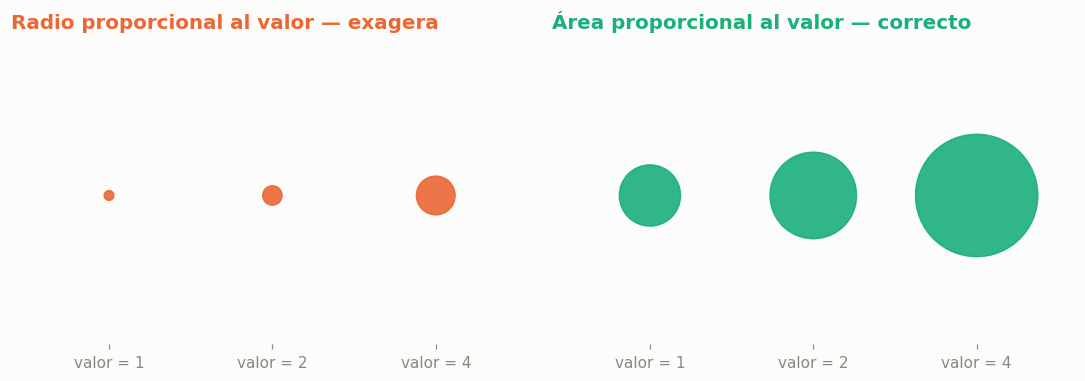

Si el radio se duplica, el área se cuadruplica:
  valor 1 -> 2  es el doble, pero el círculo se ve 4 veces más grande
  valor 1 -> 4  es el cuádruple, pero el círculo se ve 16 veces más grande


In [24]:
valores = np.array([1, 2, 4])
x = np.array([1, 2, 3])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)

# Izquierda: el RADIO proporcional al valor (incorrecto)
ax1.scatter(x, [1, 1, 1], s=(valores * 40) ** 2 / 40, color=NARANJA, alpha=0.9)
ax1.set_title("Radio proporcional al valor — exagera", color=NARANJA)

# Derecha: el ÁREA proporcional al valor (correcto)
ax2.scatter(x, [1, 1, 1], s=valores * 1600, color=VERDE, alpha=0.9)
ax2.set_title("Área proporcional al valor — correcto", color=VERDE)

for ax in (ax1, ax2):
    ax.set_xticks(x); ax.set_xticklabels([f"valor = {v}" for v in valores])
    ax.set_yticks([]); ax.set_xlim(0.4, 3.6); ax.set_ylim(0.4, 1.6)
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

fig.tight_layout()
plt.show()

print("Si el radio se duplica, el área se cuadruplica:")
print("  valor 1 -> 2  es el doble, pero el círculo se ve 4 veces más grande")
print("  valor 1 -> 4  es el cuádruple, pero el círculo se ve 16 veces más grande")

> **La regla:** en burbujas, mapas de símbolos e infografías, el área —no el radio— debe
> ser proporcional al valor. La mayoría de las herramientas lo hacen bien por defecto; las
> infografías de prensa, casi nunca.

## 3.5 · Los cinco principios

> 1. **En barras y áreas, el eje empieza en cero.** Sin excepciones.
> 2. **Las marcas del eje van a distancias proporcionales**, salvo que la escala sea
>    logarítmica y esté declarada.
> 3. **El agrupamiento es una decisión.** Prueba varios anchos y muestra el que representa
>    los datos, no el que apoya tu conclusión.
> 4. **El área codifica el valor**, no el radio.
> 5. **La prueba final:** si alguien que lee tu gráfico y luego ve los datos crudos se
>    sorprende, el gráfico estaba mal.

---
# Cierre

## Lo que lograste hoy

- [x] Ubicar cuantiles y usarlos como medidas de posición
- [x] Poner un número a la asimetría, y saber qué predice del histograma
- [x] Demostrar con un solo dato qué medidas son robustas y cuáles no
- [x] Aplicar la regla de Tukey y la puntuación z, y explicar por qué no coinciden
- [x] Ver cómo un atípico se esconde detrás de su propio efecto sobre la desviación
- [x] Enumerar los cuatro impactos de un valor extremo
- [x] Resolver una asimetría transformando en vez de borrando
- [x] Reconocer las cuatro formas de mentir con un gráfico honesto

## Las cinco ideas que hay que llevarse

1. **Robusto significa que un puñado de extremos no lo mueve.** Mediana, RIC y MAD lo son;
   media, desviación y rango no.
2. **Un atípico es un valor lejano según una regla que tú elegiste**, no un error.
3. **La puntuación z se contamina con el atípico que busca.** Tukey no.
4. **Antes de borrar, transforma.** El logaritmo resolvió miles de atípicos sin perder una
   sola fila.
5. **Un gráfico puede mentir sin falsificar un dato**: basta el eje, la escala, el
   agrupamiento o el área.

---


## Para la sesión 6 · sábado 5 de septiembre · presencial

- **Lee OpenIntro Statistics, cap. 1.**
- Mañana pasamos de **una** variable a **dos**: tablas de contingencia, comparación de
  distribuciones entre grupos, correlación, y la diferencia entre asociación y causalidad.
  Ahí resolvemos el misterio que quedó abierto ayer: **por qué los diamantes de mejor
  tallado son los más baratos.**
- Mañana hay **taller de la Entrega 1** dentro de la clase. Trae tu base limpia y el
  análisis univariado avanzado.
- **La Entrega 1 es el lunes 7.**


---
<small>Fundamentos de estadística para la analítica de datos · Universidad Central ·
Maestría en Analítica de Datos · Grupo 4M · 2026-2 · Diana Angélica Pulido</small>